In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import mannwhitneyu
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()
engine = create_engine(os.getenv("DATABASE_URL"))

df = pd.read_sql("SELECT * FROM vw_posting_with_skills", engine)
print(df.shape)
df.head()

(1280, 12)


,posting_id,job_title,city_name,company_name,role_canonical,seniority_level,salary_mid_inr,has_salary_disclosed,exp_min_years,exp_max_years,source_site,skills
0,1380,Branch Operations Coordinator Kings Park Shopp...,NaN,Wells Fargo,other,Mid-Level,NaN,False,1.0,4.0,timesjobs,None
1,1381,Personal Banker Indian Harbour Beach,NaN,Wells Fargo,other,Mid-Level,NaN,False,0.0,1.0,timesjobs,None
2,1382,Relationship Manager - GL South,Visakhapatnam,Bajaj finserv,other,Mid-Level,NaN,False,4.0,7.0,timesjobs,[Reporting]
3,1383,Skill,Bellary,Equitas Micro Finance India Pvt Ltd,other,Mid-Level,NaN,False,0.0,5.0,timesjobs,None
4,1384,Senior Executive - Debt Management Servi...,Jamnagar,Bajaj finserv,other,Senior,NaN,False,3.0,5.0,timesjobs,None


In [3]:
df_salary = df[df['has_salary_disclosed'] == True].copy()
print(f"{len(df_salary)} postings with disclosed salary out of {len(df)} total")

141 postings with disclosed salary out of 1280 total


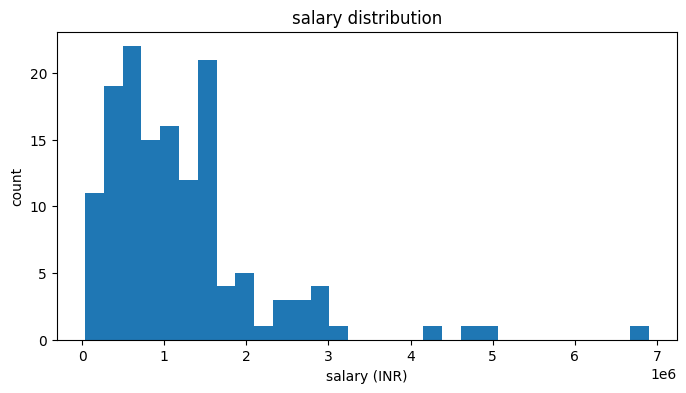

mean: 1190255.319148936
median: 1000000.0


In [4]:
plt.figure(figsize=(8, 4))
plt.hist(df_salary['salary_mid_inr'], bins=30)
plt.xlabel('salary (INR)')
plt.ylabel('count')
plt.title('salary distribution')
plt.savefig('../data/processed/salary_distribution.png')
plt.show()

print('mean:', df_salary['salary_mid_inr'].mean())
print('median:', df_salary['salary_mid_inr'].median())

In [5]:
top_skills = ['SQL', 'Python', 'Power BI', 'Excel', 'Machine Learning', 'Data Visualization']

for skill in top_skills:
    col_name = 'has_' + skill.lower().replace(' ', '_')
    df_salary[col_name] = df_salary['skills'].apply(
        lambda s: skill in s if isinstance(s, (list, np.ndarray)) else False
    )

df_salary['experience_years'] = df_salary['exp_min_years'].fillna(df_salary['exp_min_years'].median())

feature_cols = ['experience_years'] + ['has_' + s.lower().replace(' ', '_') for s in top_skills]
df_model = df_salary.dropna(subset=['salary_mid_inr'])
df_model[feature_cols].head()

,experience_years,has_sql,has_python,has_power_bi,has_excel,has_machine_learning,has_data_visualization
250,15.0,False,False,False,False,False,False
251,1.0,False,True,False,False,False,False
430,3.0,False,False,False,False,False,False
450,16.0,False,False,False,False,False,False
528,4.0,False,False,False,False,False,False


In [6]:
df_model['log_salary'] = np.log(df_model['salary_mid_inr'])

X = df_model[feature_cols].astype(float)
X = sm.add_constant(X)
y_log = df_model['log_salary']

model_log = sm.OLS(y_log, X).fit()
print(model_log.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.442
Date:                Tue, 04 Aug 2026   Prob (F-statistic):              0.194
Time:                        14:51:14   Log-Likelihood:                -172.24
No. Observations:                 141   AIC:                             360.5
Df Residuals:                     133   BIC:                             384.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     13

In [ ]:
log_coefs = model_log.params.drop('const')
pct_effect = (np.exp(log_coefs) - 1) * 100
pct_effect.sort_values(ascending=False)

In [ ]:
coefs_log = model_log.params.reset_index()
coefs_log.columns = ['feature', 'coefficient']
coefs_log.to_csv('../data/processed/regression_coefficients_log.csv', index=False)
coefs_log

NameError: name 'model' is not defined

In [ ]:
with_ml = df_model[df_model['has_machine_learning'] == True]['salary_mid_inr']
without_ml = df_model[df_model['has_machine_learning'] == False]['salary_mid_inr']

print(f"with ML: n={len(with_ml)}, median={with_ml.median()}")
print(f"without ML: n={len(without_ml)}, median={without_ml.median()}")

if len(with_ml) >= 5 and len(without_ml) >= 5:
    stat, p_value = mannwhitneyu(with_ml, without_ml, alternative='two-sided')
    print(f"p-value: {p_value:.4f}")
else:
    print("sample too small for a reliable test")

with ML: n=23, median=900000.0
without ML: n=118, median=1000000.0
p-value: 0.5897


In [ ]:
q1, q3 = df_model['salary_mid_inr'].quantile([0.25, 0.75])
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df_model[(df_model['salary_mid_inr'] < lower) | (df_model['salary_mid_inr'] > upper)]
print(f"{len(outliers)} outliers out of {len(df_model)} rows")
outliers[['job_title', 'company_name', 'salary_mid_inr']].sort_values('salary_mid_inr', ascending=False)

9 outliers out of 141 rows


,job_title,company_name,salary_mid_inr
430,Data Analyst In Dubai,Anshi Immigration Private Limited,6900000.0
721,Senior Data Analyst Jobs In Australia-Singapor...,Ozira Immigrations Services Private Limited,4900000.0
765,Data Analyst Jobs In Luxembourg-Netherland-Ger...,Ozira Immigrations Services Private Limited,4800000.0
768,Data Analyst - Manager (Fixed Term Contract),FedEx Express Transportation and Supply Chain ...,4250000.0
1110,Senior Data Analyst Top b2c product company only,Staffnixcom,3200000.0
897,Data Analyst,Talent500 by ANSR,3000000.0
920,Senior Data Analyst,Masai,3000000.0
1056,Power BI Developer/ Data Analyst,GoHyre,3000000.0
1171,Business Analyst - Data Integration,Hashone Careers Private Limited,3000000.0
